In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    "Model": ["Claude Opus", "Gemini 2.5", "GPT-4.1", "LLaMA 3.3", "GPT-4o Turbo"],
    "Elo Score": [1496, 1486, 1287, 1000, 1100],   # Higher is better
    "Quality Index": [0.88, 0.83, 0.99, 0.74, 0.88],  # Higher is better
    "Latency (s)": [1.13, 0.51, 0.48, 0.59, 0.60],  # Lower is better
    "Context Score": [5, 4, 4, 3, 4],  # Higher is better
    "Cost ($)": [15, 2.8, 10, 3.5, 15]  # Lower is better
}

df = pd.DataFrame(data)

print("\nOriginal Decision Matrix:\n")
print(df)


Original Decision Matrix:

          Model  Elo Score  Quality Index  Latency (s)  Context Score  \
0   Claude Opus       1496           0.88         1.13              5   
1    Gemini 2.5       1486           0.83         0.51              4   
2       GPT-4.1       1287           0.99         0.48              4   
3     LLaMA 3.3       1000           0.74         0.59              3   
4  GPT-4o Turbo       1100           0.88         0.60              4   

   Cost ($)  
0      15.0  
1       2.8  
2      10.0  
3       3.5  
4      15.0  


In [3]:
matrix = df.iloc[:, 1:].values
weights = np.array([0.25, 0.25, 0.15, 0.20, 0.15])
impacts = np.array([1, 1, -1, 1, -1])

In [4]:
norm_matrix = matrix / np.sqrt((matrix**2).sum(axis=0))

In [5]:
weighted_matrix = norm_matrix * weights

In [6]:
ideal_best = np.where(
    impacts == 1,
    weighted_matrix.max(axis=0),
    weighted_matrix.min(axis=0)
)

ideal_worst = np.where(
    impacts == 1,
    weighted_matrix.min(axis=0),
    weighted_matrix.max(axis=0)
)

In [7]:
dist_best = np.sqrt(((weighted_matrix - ideal_best) ** 2).sum(axis=1))
dist_worst = np.sqrt(((weighted_matrix - ideal_worst) ** 2).sum(axis=1))

In [8]:
topsis_score = dist_worst / (dist_best + dist_worst)
df["TOPSIS Score"] = topsis_score
df["Rank"] = df["TOPSIS Score"].rank(ascending=False)
df = df.sort_values("Rank")

print("\nFinal Ranking using TOPSIS:\n")
print(df)


Final Ranking using TOPSIS:

          Model  Elo Score  Quality Index  Latency (s)  Context Score  \
1    Gemini 2.5       1486           0.83         0.51              4   
2       GPT-4.1       1287           0.99         0.48              4   
3     LLaMA 3.3       1000           0.74         0.59              3   
4  GPT-4o Turbo       1100           0.88         0.60              4   
0   Claude Opus       1496           0.88         1.13              5   

   Cost ($)  TOPSIS Score  Rank  
1       2.8      0.781326   1.0  
2      10.0      0.609475   2.0  
3       3.5      0.557260   3.0  
4      15.0      0.398009   4.0  
0      15.0      0.392134   5.0  


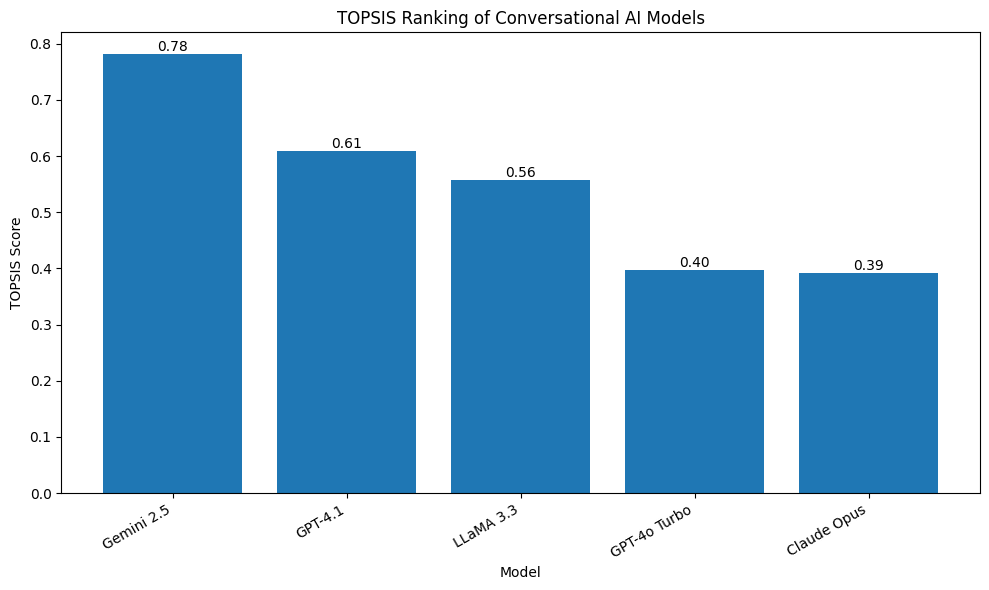

In [9]:
plt.figure(figsize=(10, 6))
bars = plt.bar(df["Model"], df["TOPSIS Score"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )
plt.title("TOPSIS Ranking of Conversational AI Models")
plt.xlabel("Model")
plt.ylabel("TOPSIS Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()